In [33]:
%load_ext autoreload
%autoreload 2

import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from pathlib import Path
import jax
import jax.numpy as jnp
from flax.training import checkpoints
from flax import serialization
from agents.a2c_rnn_flax import A2CRNNFlax, init_network_and_params
from environments.components.train_state import create_train_state
from environments.treadmill_env_jax import treadmill_session_default_params
import matplotlib.pyplot as plt
from nb_analysis_tools import load_trajectory_data, parse_behavioral_data
from aux_funcs import format_plot, format_pc_plot
import numpy as np
from sklearn.decomposition import PCA
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
import seaborn as sns
from copy import copy
from nb_dynamics_plotting import *

plt.rcParams['font.family'] = 'Helvetica Light'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# --- CONFIGURATION ---
CHECKPOINT_PATH = "../../../checkpoints/fixed_exp_gru_reward_decay_net0/checkpoint_450"  # path to directory with checkpoint
HIDDEN_SIZE = 64
ACTION_SIZE = 2
OBS_SIZE = 4
RNN_TYPE = "GRU"
UNIT_NOISE_STD = 1e-2
LEARNING_RATE = 0
SEED = 0
NUM_ENVS = 1

# Configuration
CONFIG = {
    'hidden_size': 64,
    'action_size': 2,
    'obs_size': 4,
    'rnn_type': 'GRU',  # or 'VANILLA'
    'unit_noise_std': 0.0,
}

# Define input context
# Input format: [obs(4), prev_action_onehot(2), prev_reward(1)]
input_dim = CONFIG['obs_size'] + CONFIG['action_size'] + 1

In [5]:
# --- INITIALIZE NETWORK + TRAIN STATE ---
rng_key = jax.random.key(SEED)
net_init_key, rng_key = jax.random.split(rng_key)

network, params = init_network_and_params(
    hidden_size=HIDDEN_SIZE,
    action_size=ACTION_SIZE,
    obs_size=OBS_SIZE,
    rnn_type=RNN_TYPE,
    unit_noise_std=UNIT_NOISE_STD,
    rng_key=net_init_key,
)

train_state = create_train_state(
    rng_key=rng_key,
    obs_size=OBS_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_envs=NUM_ENVS,
    learning_rate=LEARNING_RATE,
    params=params,
)

# --- LOAD CHECKPOINT ---
print(f"Loading checkpoint from {CHECKPOINT_PATH} ...")
ckpt_path = Path(CHECKPOINT_PATH).resolve()

restored = checkpoints.restore_checkpoint(ckpt_dir=ckpt_path, target=train_state)
params = restored.params
train_state = restored
print("Model loaded successfully!")

# --- PROBE WEIGHTS ---
flat_params = jax.tree_util.tree_map(lambda x: x.shape, train_state.params)
print("Parameter shapes:")
print(flat_params)

try:
    print("Actor dense kernel sample:")
    print(train_state.params['actor_dense']['kernel'][:3, :3])
except KeyError:
    print("Could not find 'actor_dense' in params; inspect `flat_params` keys to locate structure.")

Loading checkpoint from ../../../checkpoints/fixed_exp_gru_reward_decay_net0/checkpoint_450 ...
Model loaded successfully!
Parameter shapes:
{'params': {'actor': {'bias': (2,), 'kernel': (64, 2)}, 'critic': {'bias': (1,), 'kernel': (64, 1)}, 'env_quality_prediction': {'bias': (3,), 'kernel': (64, 3)}, 'exp_filtered_reward_rate_prediction': {'bias': (1,), 'kernel': (64, 1)}, 'obs_pred_layer_1': {'bias': (16,), 'kernel': (64, 16)}, 'obs_prediction': {'bias': (5,), 'kernel': (16, 5)}, 'rnn_actor': {'hn': {'bias': (64,), 'kernel': (64, 64)}, 'hr': {'kernel': (64, 64)}, 'hz': {'kernel': (64, 64)}, 'in': {'bias': (64,), 'kernel': (7, 64)}, 'ir': {'bias': (64,), 'kernel': (7, 64)}, 'iz': {'bias': (64,), 'kernel': (7, 64)}}, 'rnn_critic': {'hn': {'bias': (64,), 'kernel': (64, 64)}, 'hr': {'kernel': (64, 64)}, 'hz': {'kernel': (64, 64)}, 'in': {'bias': (64,), 'kernel': (7, 64)}, 'ir': {'bias': (64,), 'kernel': (7, 64)}, 'iz': {'bias': (64,), 'kernel': (7, 64)}}}}
Actor dense kernel sample:
Coul

In [ ]:
FIXED_EXP_GRU_REWARD_DECAY_NETWORKS = [
    # '../../../results/fixed_exp_gru_reward_decay_net0/trajectories_20260409_181731.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net1/trajectories_20260409_185208.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net2/trajectories_20260409_192646.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net3/trajectories_20260409_200130.pkl',
    '../../../results/fixed_exp_gru_reward_decay_net4/trajectories_20260409_203615.pkl',
]

FIXED_EXP_GRU_REWARD_DECAY_CHECKPOINTS = [
    # '../../../checkpoints/fixed_exp_gru_reward_decay_net0/checkpoint_450',
    '../../../checkpoints/fixed_exp_gru_reward_decay_net1/checkpoint_450',
    '../../../checkpoints/fixed_exp_gru_reward_decay_net2/checkpoint_450',
    '../../../checkpoints/fixed_exp_gru_reward_decay_net3/checkpoint_450',
    '../../../checkpoints/fixed_exp_gru_reward_decay_net4/checkpoint_450',
]

REWARD_RATE_THRESHOLD = 0.062

FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS = [
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net0/trajectories_20260511_174228.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net1/trajectories_20260511_183442.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net2/trajectories_20260511_192657.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net3/trajectories_20260511_201932.pkl',
    '../../../results/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net4/trajectories_20260511_211213.pkl',
]

FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS = [
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net0/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net1/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net2/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net3/checkpoint_0',
    '../../../checkpoints/fixed_exp_gru_initial_prob_offset_middle_0p6_init_scale_0p2_v3_net4/checkpoint_0',
]

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


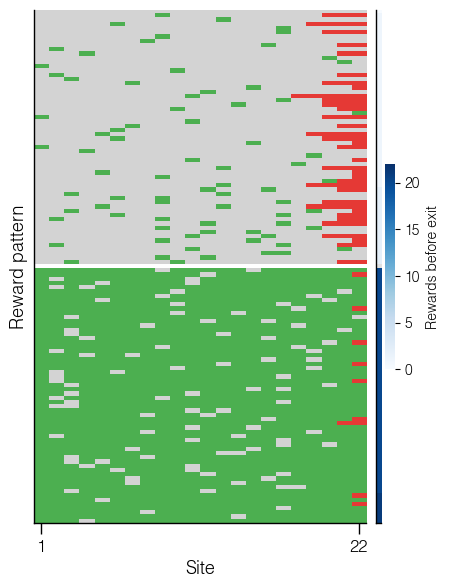

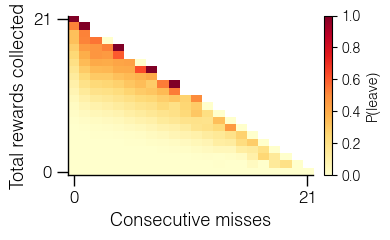

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


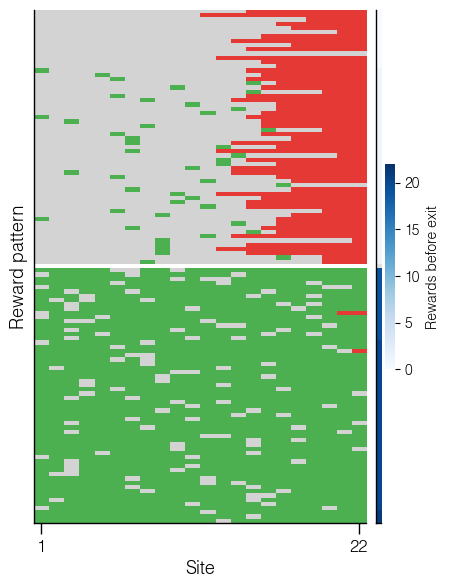

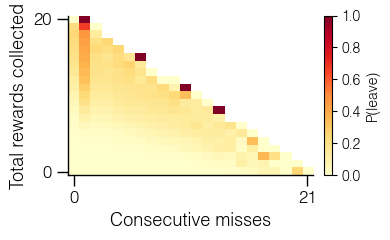

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


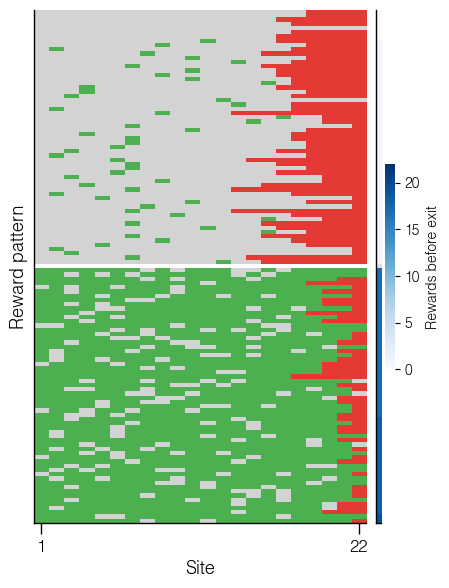

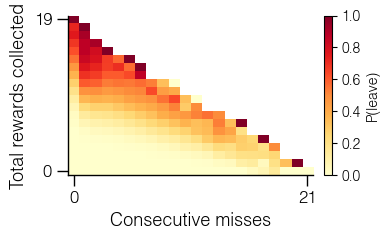

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


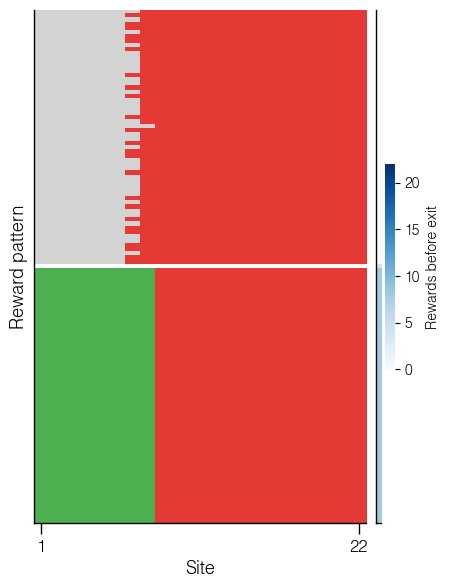

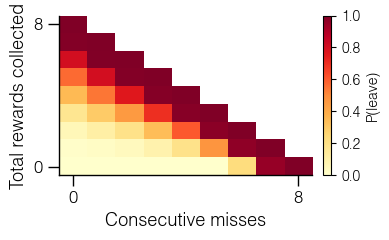

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


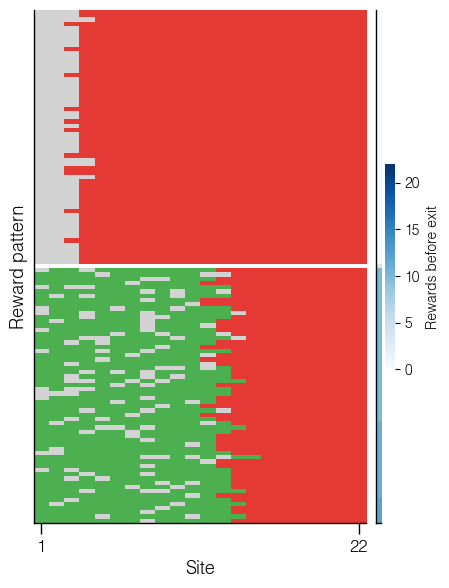

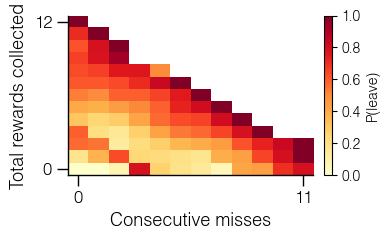

In [17]:
for net_idx in range(5):
    dir_path = FIXED_EXP_GRU_REWARD_DECAY_NETWORKS[net_idx]

    traj_data = {}
    for env_idx in range(1):
        traj_data_raw = load_trajectory_data(dir_path)
        traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
        for key in traj_data_env.keys():
            if key in traj_data:
                traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
            else:
                traj_data[key] = traj_data_env[key]

    reward_patterns, exit_sites, fig_exit, fig_prob = find_exit_site_all_reward_patterns(
        ckpt_path=FIXED_EXP_GRU_REWARD_DECAY_CHECKPOINTS[net_idx],
        train_state=train_state,
        network=network,
        traj_data=traj_data,
        odor_idx=3, odor_offset=12, odor_on=6, odor_off=1,
        n_sites=22, n_stay_threshold=3,
    )

    plt.show(fig_exit)
    plt.close(fig_exit)
    plt.show(fig_prob)
    plt.close(fig_prob)

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


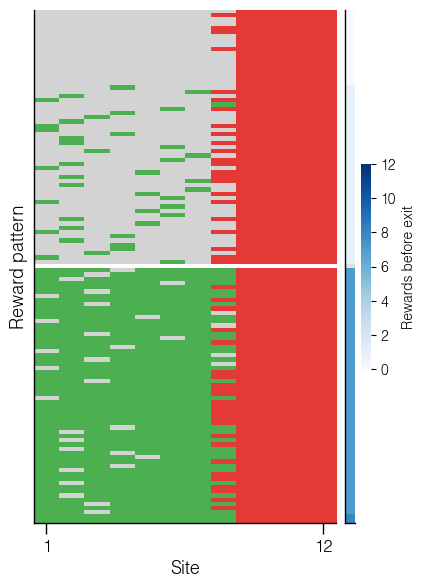

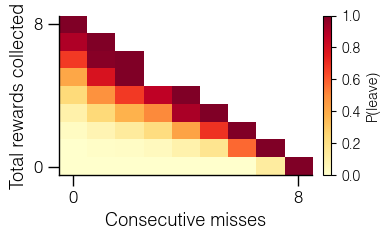

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


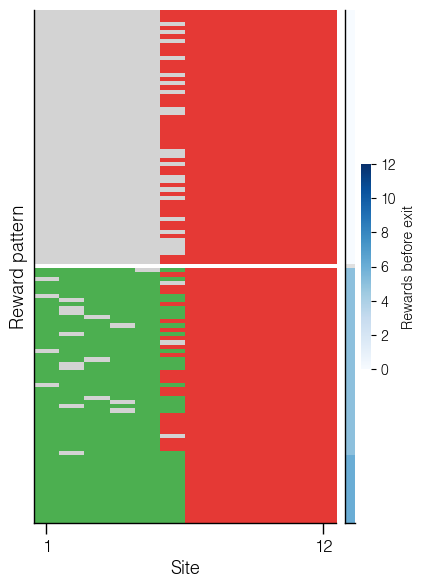

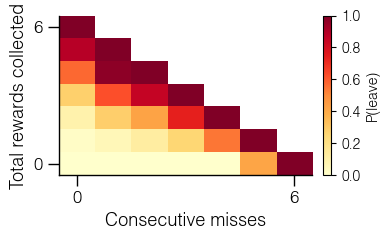

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


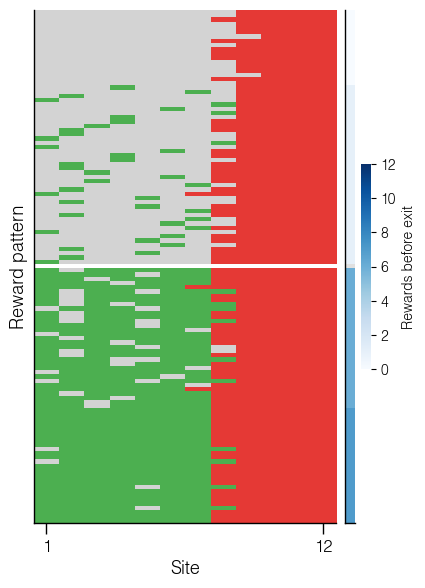

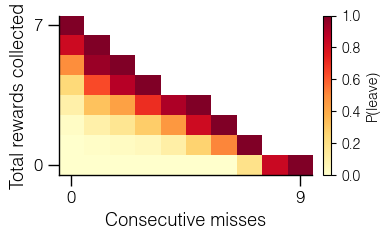

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


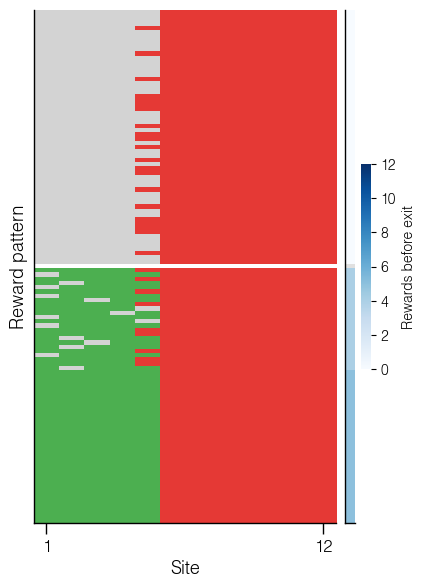

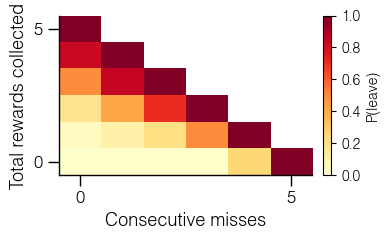

<string>:125: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


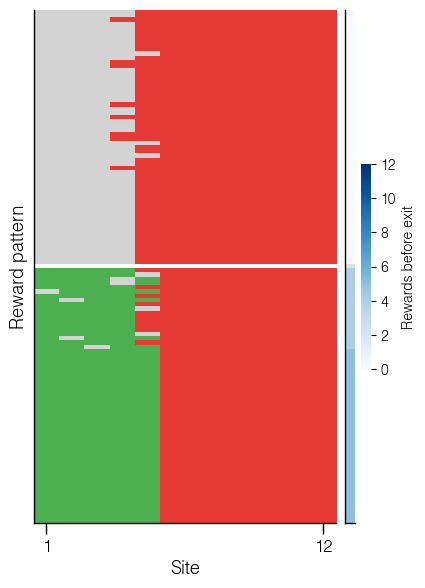

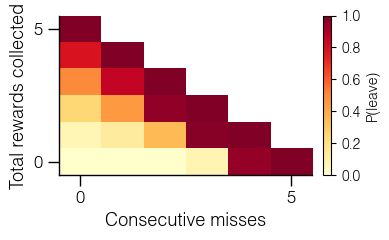

In [18]:
for net_idx in range(5):
    dir_path = FIXED_EXP_GRU_REWARD_DECAY_NETWORKS[net_idx]

    traj_data = {}
    for env_idx in range(1):
        traj_data_raw = load_trajectory_data(dir_path)
        traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
        for key in traj_data_env.keys():
            if key in traj_data:
                traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
            else:
                traj_data[key] = traj_data_env[key]

    reward_patterns, exit_sites, fig_exit, fig_prob = find_exit_site_all_reward_patterns(
        ckpt_path=FIXED_EXP_GRU_REWARD_DECAY_CHECKPOINTS[net_idx],
        train_state=train_state,
        network=network,
        traj_data=traj_data,
        odor_idx=2, odor_offset=12, odor_on=6, odor_off=1,
        n_sites=12, n_stay_threshold=3,
    )

    plt.show(fig_exit)
    plt.close(fig_exit)
    plt.show(fig_prob)
    plt.close(fig_prob)

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


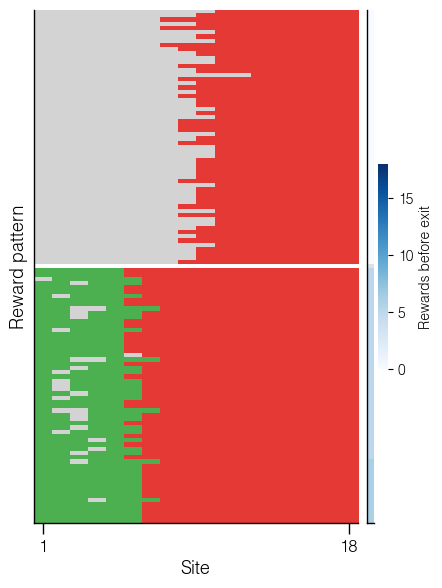

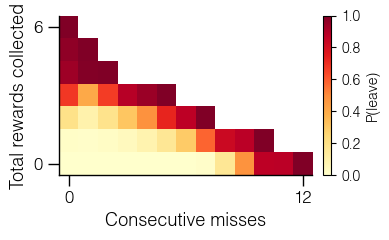

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


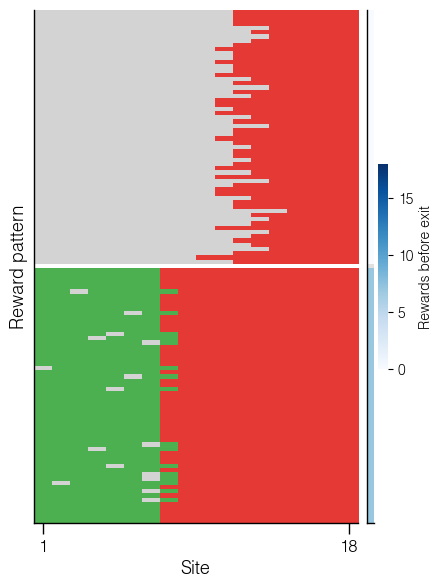

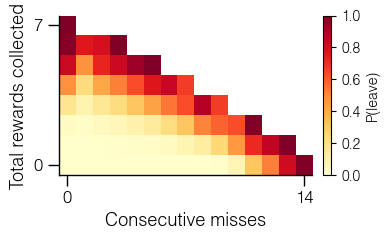

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


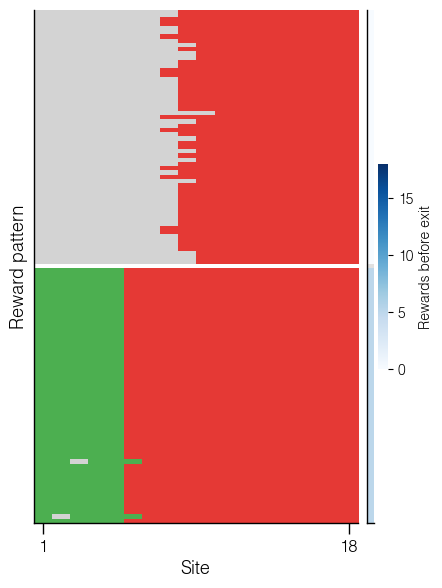

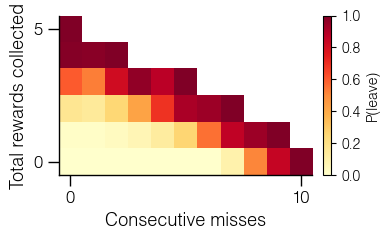

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


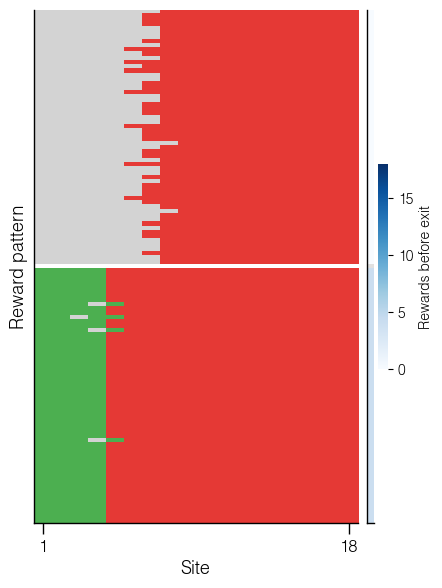

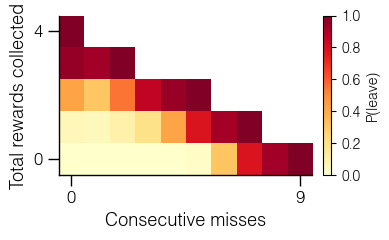

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


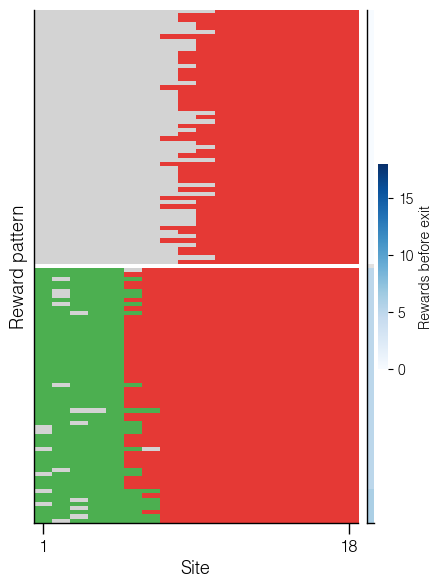

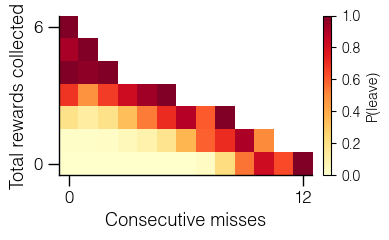

In [5]:
for net_idx in range(5):
    dir_path = FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS[net_idx]

    traj_data = {}
    for env_idx in range(1):
        traj_data_raw = load_trajectory_data(dir_path)
        traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
        for key in traj_data_env.keys():
            if key in traj_data:
                traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
            else:
                traj_data[key] = traj_data_env[key]

    reward_patterns, exit_sites, fig_exit, fig_prob = find_exit_site_all_reward_patterns(
        ckpt_path=FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS[net_idx],
        train_state=train_state,
        network=network,
        traj_data=traj_data,
        odor_idx=2, odor_offset=12, odor_on=6, odor_off=1,
        n_sites=18, n_stay_threshold=3,
    )

    plt.show(fig_exit)
    plt.close(fig_exit)
    plt.show(fig_prob)
    plt.close(fig_prob)

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


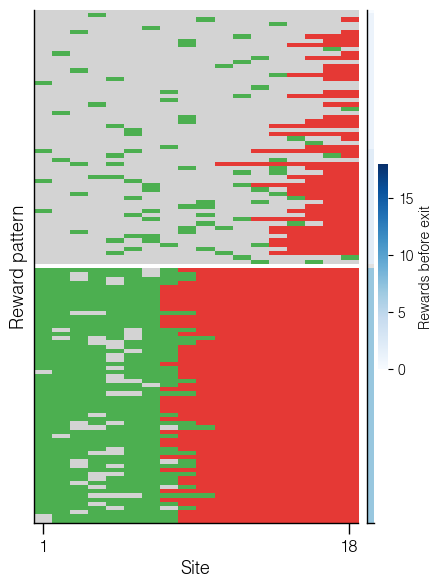

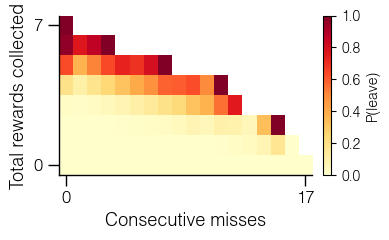

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


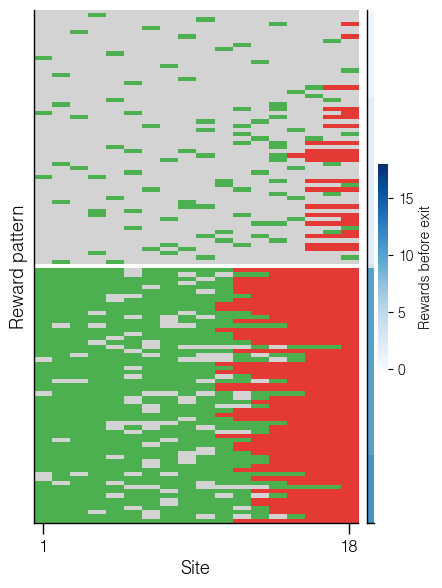

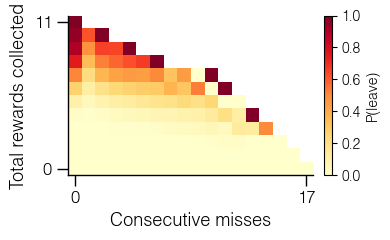

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


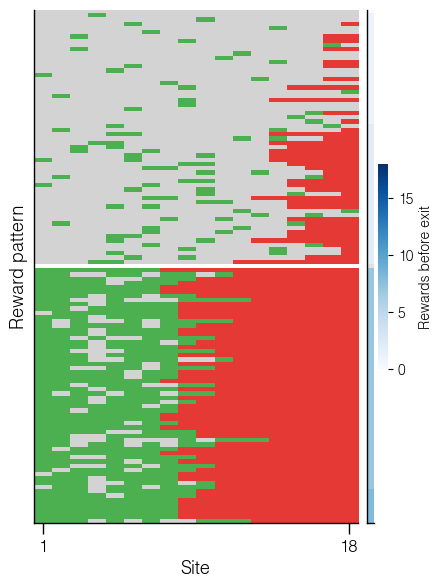

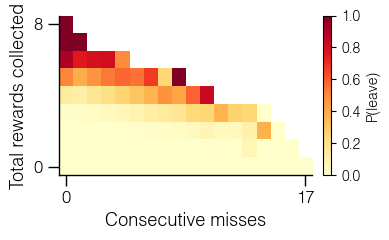

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


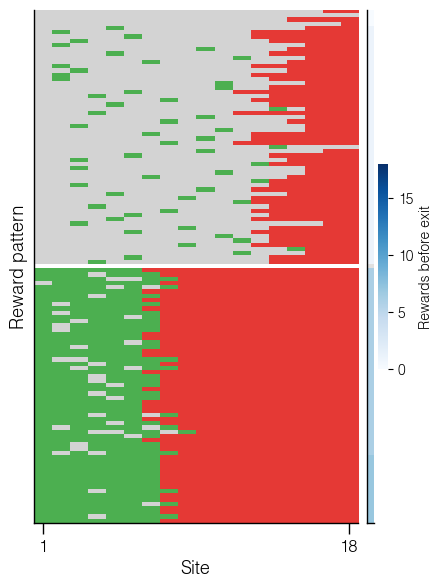

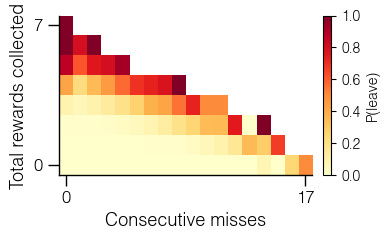

/home/david.bell/work/favorably_connected_2/code/nb_dynamics_plotting.py:3093: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


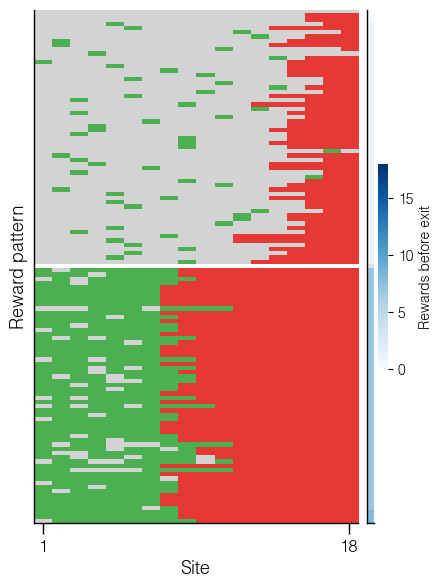

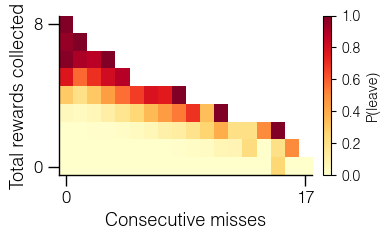

In [6]:
for net_idx in range(5):
    dir_path = FIXED_EXP_GRU_INITIAL_PROB_OFFSET_NETWORKS[net_idx]

    traj_data = {}
    for env_idx in range(1):
        traj_data_raw = load_trajectory_data(dir_path)
        traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
        for key in traj_data_env.keys():
            if key in traj_data:
                traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
            else:
                traj_data[key] = traj_data_env[key]

    reward_patterns, exit_sites, fig_exit, fig_prob = find_exit_site_all_reward_patterns(
        ckpt_path=FIXED_EXP_GRU_INITIAL_PROB_OFFSET_CHECKPOINTS[net_idx],
        train_state=train_state,
        network=network,
        traj_data=traj_data,
        odor_idx=3, odor_offset=12, odor_on=6, odor_off=1,
        n_sites=18, n_stay_threshold=3,
    )

    plt.show(fig_exit)
    plt.close(fig_exit)
    plt.show(fig_prob)
    plt.close(fig_prob)

Exit sites: [[17 30]
 [17 30]
 [16 23]
 [16 24]
 [15 24]
 [14 19]
 [13 23]
 [17 23]
 [17 24]
 [15 22]]


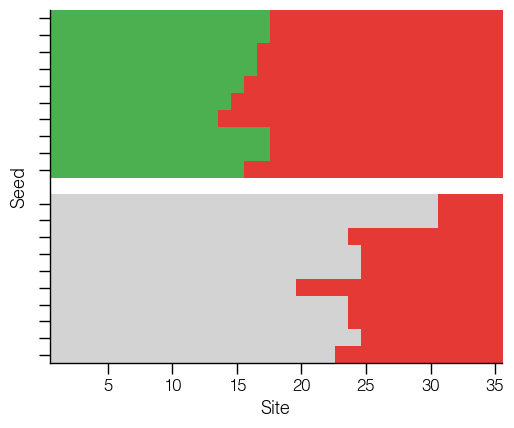

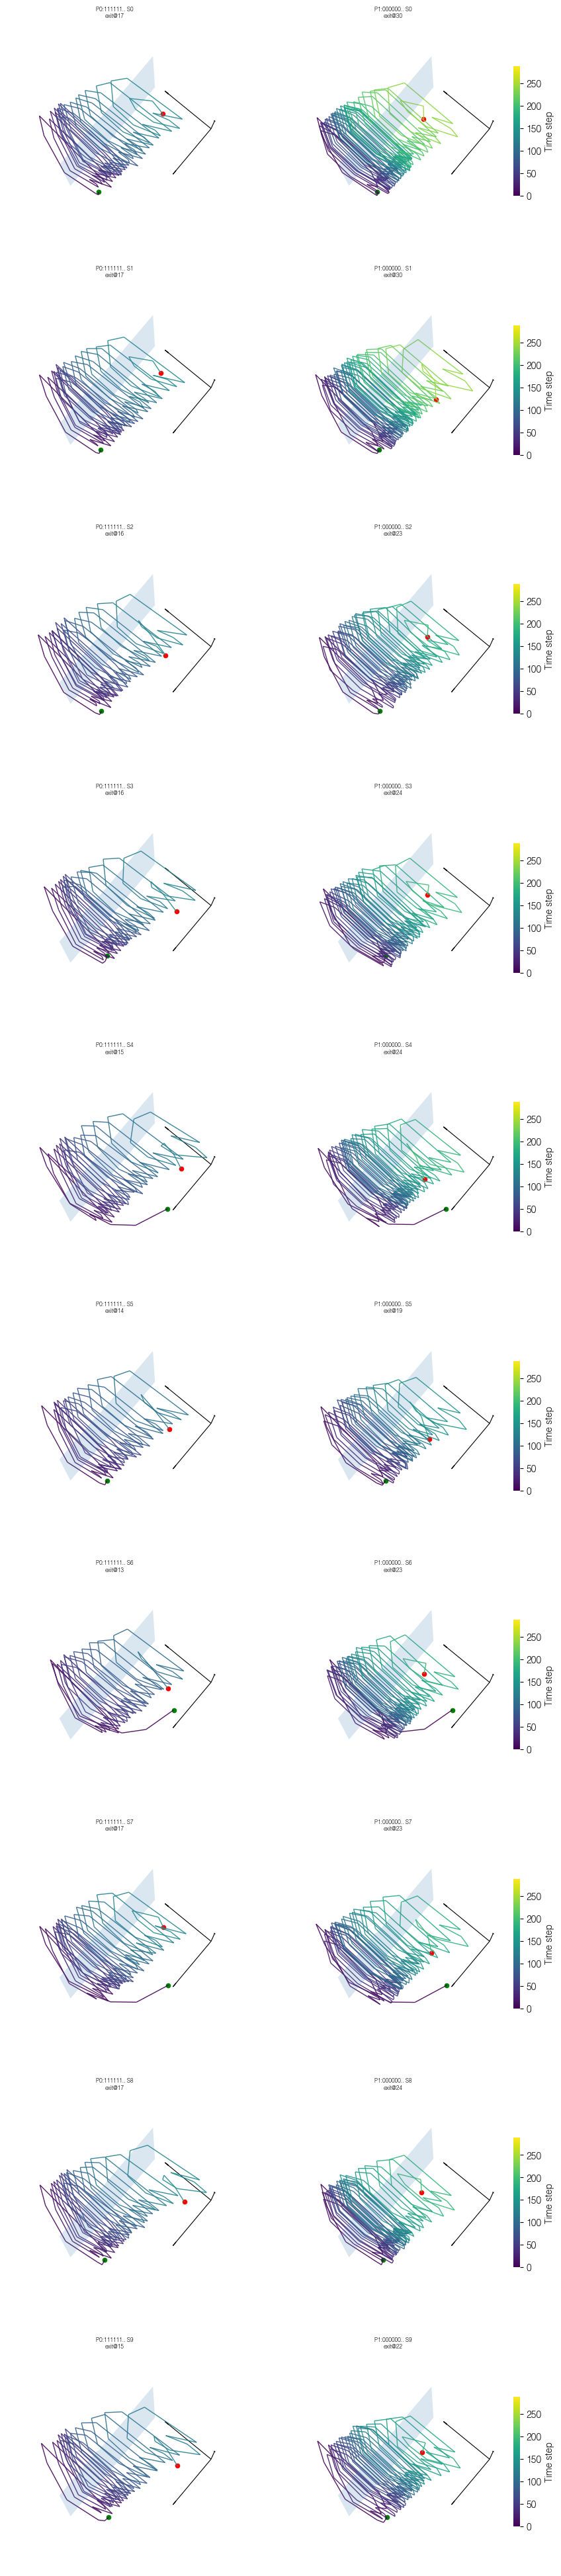

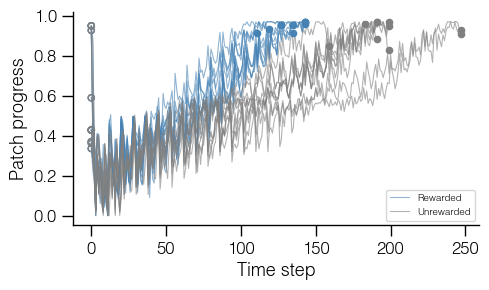

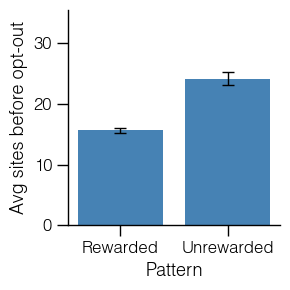

: 

In [ ]:
# PCA trajectories for two extreme reward patterns
net_idx  = 1
dir_path = FIXED_EXP_GRU_REWARD_DECAY_NETWORKS[net_idx]
ckpt_path = FIXED_EXP_GRU_REWARD_DECAY_CHECKPOINTS[net_idx]
n_sites  = 35

traj_data = {}
for env_idx in range(1):
    traj_data_raw = load_trajectory_data(dir_path)
    traj_data_env = parse_behavioral_data(traj_data_raw[env_idx])
    for key in traj_data_env.keys():
        if key in traj_data:
            traj_data[key] = np.concatenate([traj_data[key], traj_data_env[key]], axis=0)
        else:
            traj_data[key] = traj_data_env[key]

pca = PCA(n_components=3)
pca.fit(traj_data['actor_hidden'].reshape(-1, 64))

tte_data = collect_pre_odor_time_to_exit(traj_data)

reward_patterns_X = [
    [1] * n_sites,   # all rewarded
    [0] * n_sites,   # never rewarded
]

fig_matrix, fig_pca, fig_pp, fig_exit_stats, exit_sites = run_specified_reward_patterns_pca(
    reward_patterns_X,
    ckpt_path=ckpt_path,
    train_state=train_state,
    network=network,
    traj_data=traj_data,
    pca=pca,
    tte_data=tte_data,
    odor_idx=3, odor_offset=2, odor_on=6, odor_off=2,
    n_stay_threshold=3,
    n_initial_states=10,
    azim=130,
    elev=80,
    seed=2,
)

print('Exit sites:', exit_sites)
plt.show(fig_matrix)
plt.close(fig_matrix)
plt.show(fig_pca)
plt.close(fig_pca)
plt.show(fig_pp)
plt.close(fig_pp)
plt.show(fig_exit_stats)
plt.close(fig_exit_stats)
